In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv("../data/datos_finales.csv")

In [5]:
df["region"] = df["pais"].apply(lambda x: "España" if x == "ES" else "Resto Europa")


In [6]:
variables = df.select_dtypes(include="number").columns.tolist()


comparacion_multi = (
    df.groupby(["region", "generacion"])[variables]
      .mean()
      .round(2)
)

print(comparacion_multi)


                                      ID   edad  año_nacimiento  \
region       generacion                                           
España       baby boomers       67218.88  67.88         1956.12   
             gen x              68194.29  51.51         1972.49   
             gen z              68060.23  21.43         2002.57   
             millennials        67570.89  36.16         1987.84   
             silent generation  67588.80  83.72         1940.28   
Resto Europa baby boomers       78449.55  67.83         1955.52   
             gen x              79294.61  51.05         1972.33   
             gen z              77719.30  21.12         2002.24   
             millennials        79821.97  35.33         1988.04   
             silent generation  73323.81  82.83         1940.45   

                                años_educacion  decil_ingresos  \
region       generacion                                          
España       baby boomers                12.44            4.92 

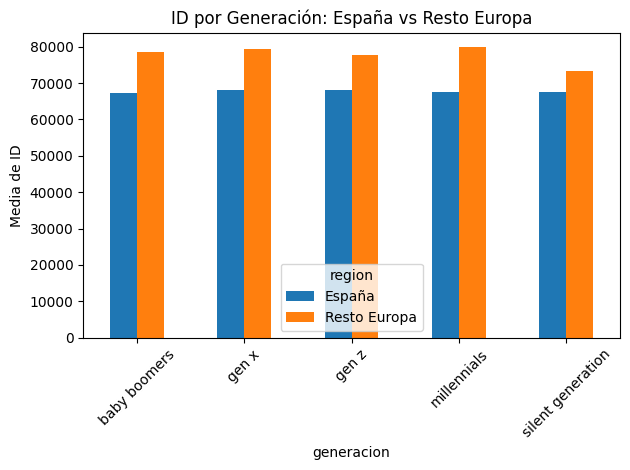

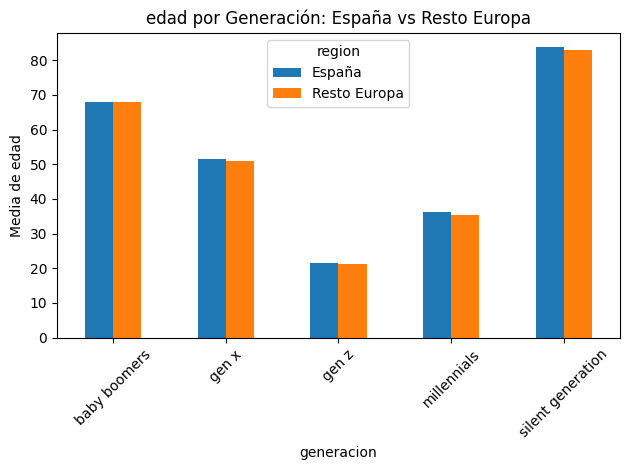

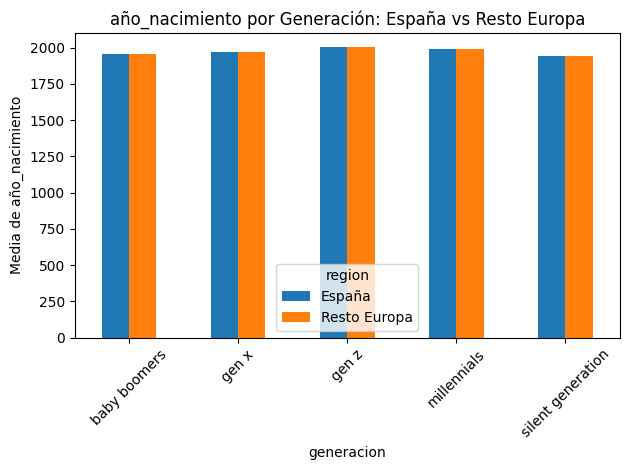

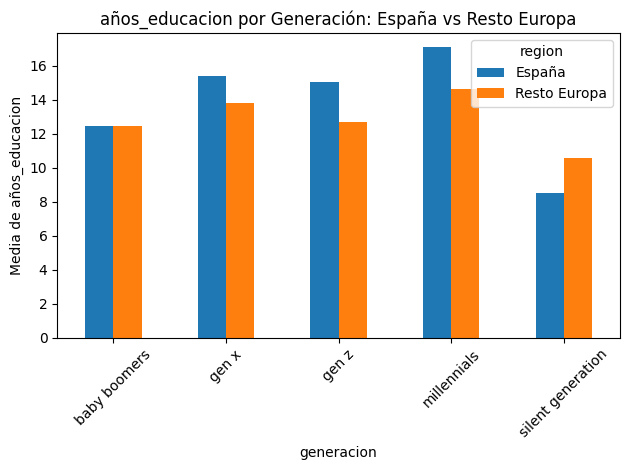

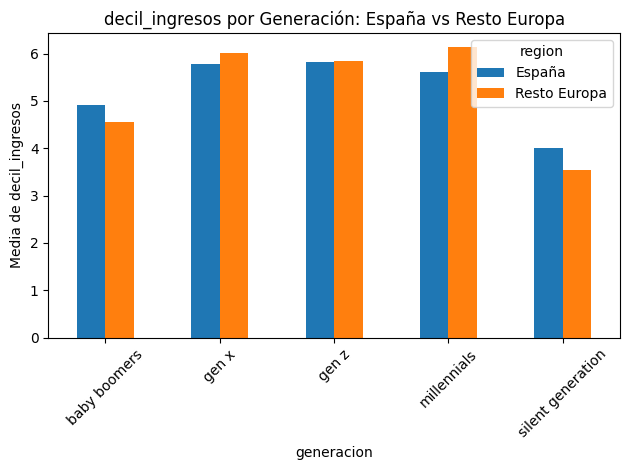

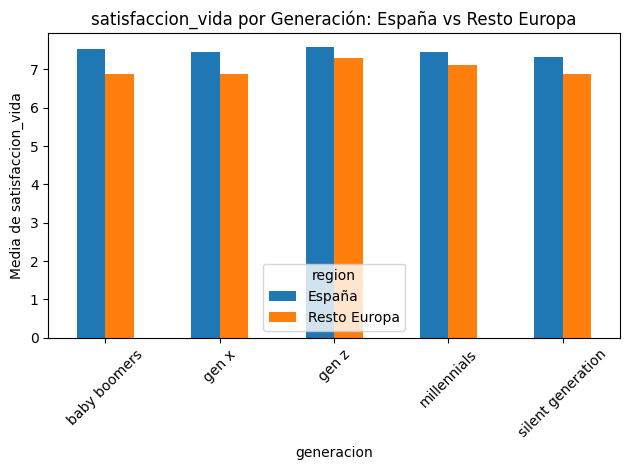

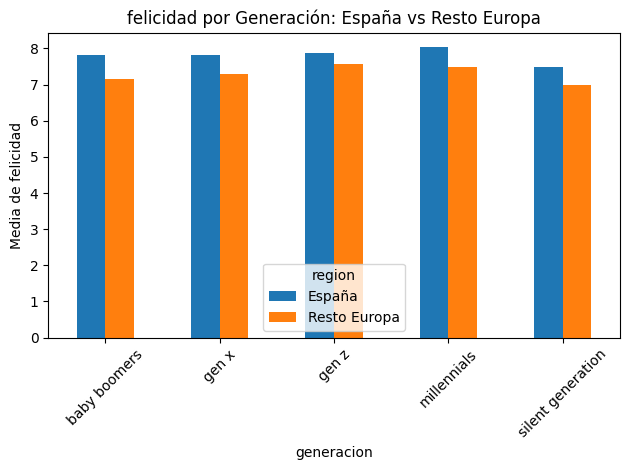

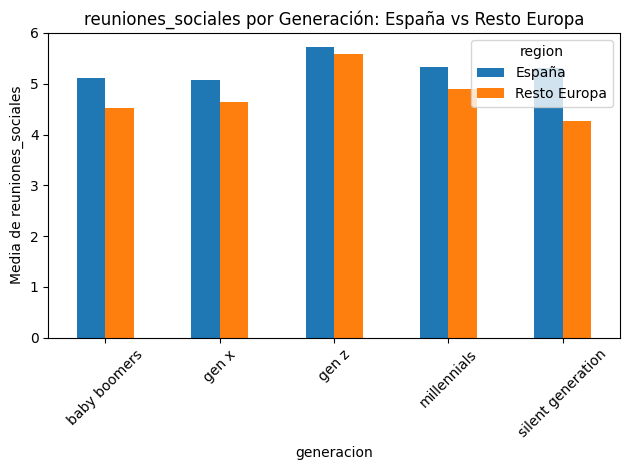

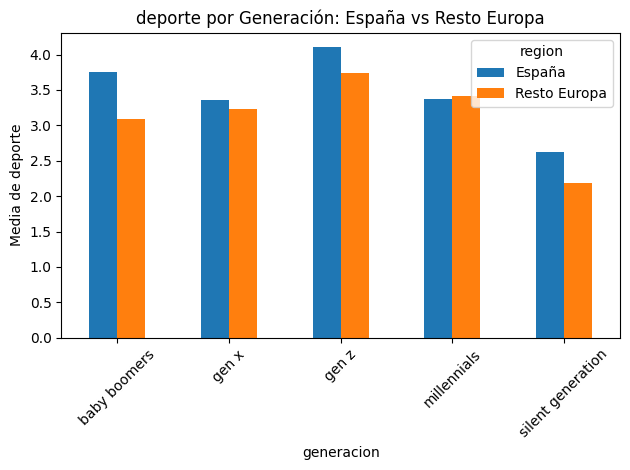

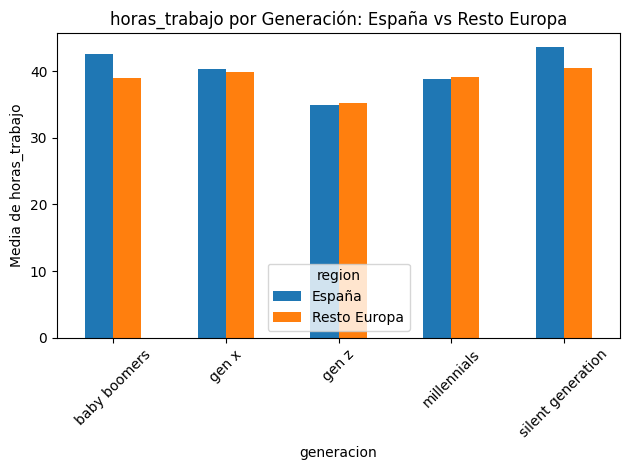

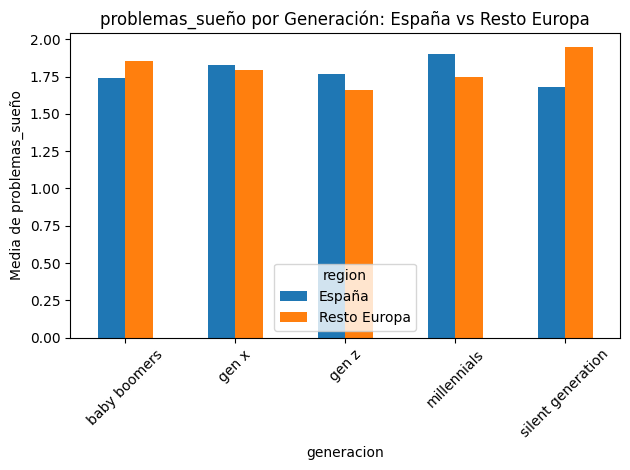

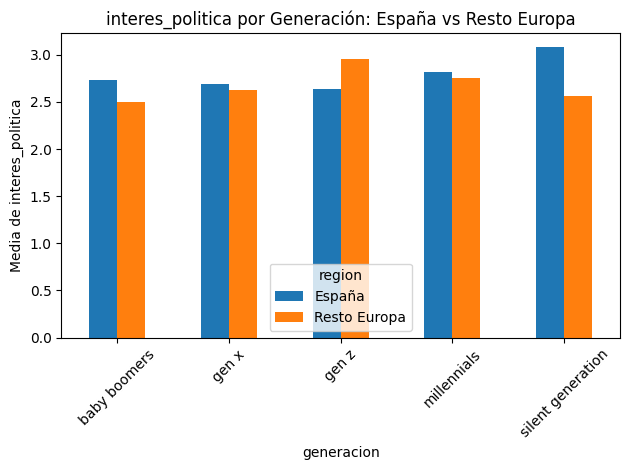

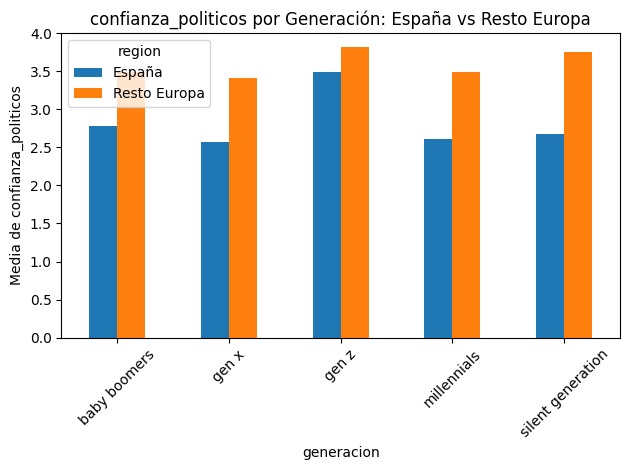

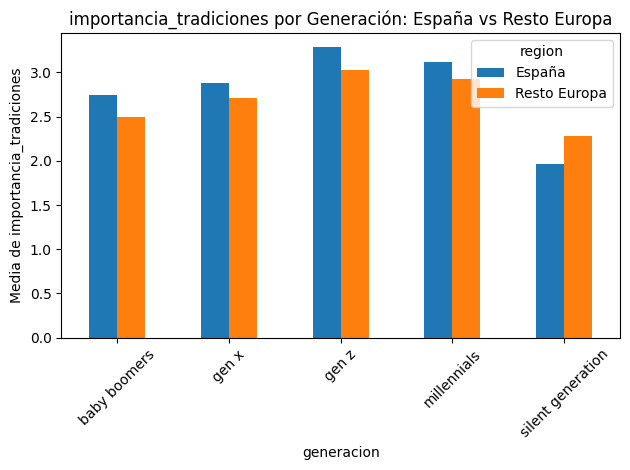

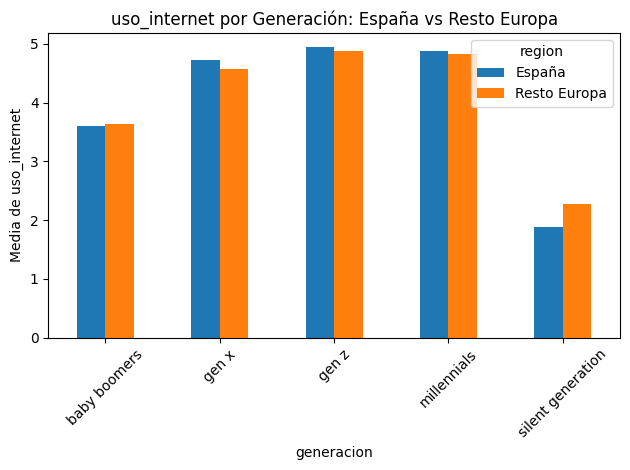

In [7]:
for variable in variables:
    
    comparacion = (
        df.groupby(["region", "generacion"])[variable]
          .mean()
          .unstack(0)
    )
    
    comparacion.plot(kind="bar")
    
    plt.ylabel(f"Media de {variable}")
    plt.title(f"{variable} por Generación: España vs Resto Europa")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [8]:
df.head(3)

,ID,pais,edad,año_nacimiento,sexo,años_educacion,estado_marital,decil_ingresos,satisfaccion_vida,felicidad,...,horas_trabajo,problemas_sueño,interes_politica,confianza_politicos,importancia_tradiciones,uso_internet,sinceridad,nivel_entendimiento,generacion,region
0,50014,AT,65.0,1958.0,hombre,12.0,desconocido,6.0,8.0,8.0,...,40.0,1.0,1.0,5.0,3.0,5.0,bastante,casi siempre,baby boomers,Resto Europa
1,50030,AT,21.0,2002.0,mujer,14.0,soltero,1.0,9.0,9.0,...,32.0,3.0,2.0,0.0,4.0,5.0,mucho,casi siempre,gen z,Resto Europa
2,50057,AT,53.0,1970.0,mujer,16.0,desconocido,5.0,10.0,9.0,...,25.0,3.0,2.0,4.0,3.0,5.0,mucho,casi siempre,gen x,Resto Europa


In [9]:
numeric_cols = df.select_dtypes(include=["number"]).columns
print(numeric_cols)

Index(['ID', 'edad', 'año_nacimiento', 'años_educacion', 'decil_ingresos',
       'satisfaccion_vida', 'felicidad', 'reuniones_sociales', 'deporte',
       'horas_trabajo', 'problemas_sueño', 'interes_politica',
       'confianza_politicos', 'importancia_tradiciones', 'uso_internet'],
      dtype='str')


In [10]:
df_esp = df[df["pais"] == "ES"]
df_world = df[df["pais"] != "ES"]

corr_esp = df_esp[numeric_cols].corr()
corr_world = df_world[numeric_cols].corr()

print("España")
print(corr_esp)

print("Resto del mundo")
print(corr_world)

España
                               ID      edad  año_nacimiento  años_educacion  \
ID                       1.000000 -0.018332        0.018332        0.023244   
edad                    -0.018332  1.000000       -1.000000       -0.321172   
año_nacimiento           0.018332 -1.000000        1.000000        0.321172   
años_educacion           0.023244 -0.321172        0.321172        1.000000   
decil_ingresos           0.013703 -0.183760        0.183760        0.395809   
satisfaccion_vida        0.030281 -0.013019        0.013019        0.001626   
felicidad                0.040092 -0.048966        0.048966        0.014450   
reuniones_sociales      -0.006006 -0.111083        0.111083        0.024651   
deporte                  0.016335 -0.071034        0.071034        0.092533   
horas_trabajo            0.002356  0.224669       -0.224669       -0.091250   
problemas_sueño         -0.002929 -0.040535        0.040535       -0.008323   
interes_politica         0.015423  0.044865  

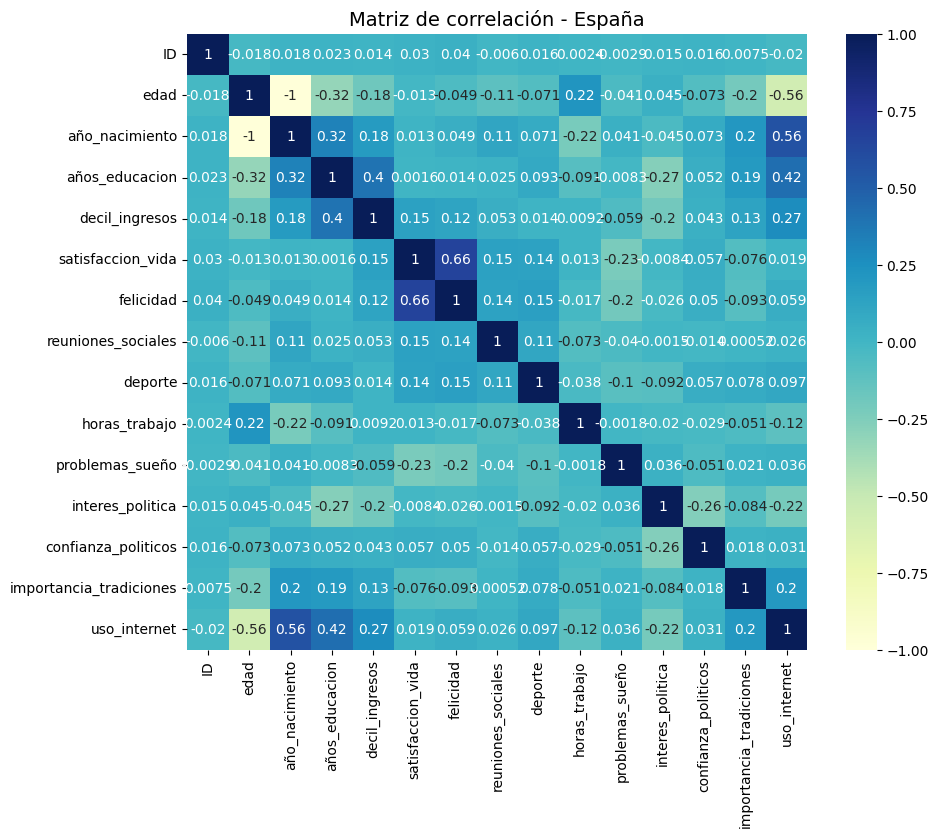

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_esp, 
            annot=True, 
             cmap="YlGnBu",
            vmin=-1, vmax=1)
plt.title("Matriz de correlación - España", fontsize=14)
plt.show()

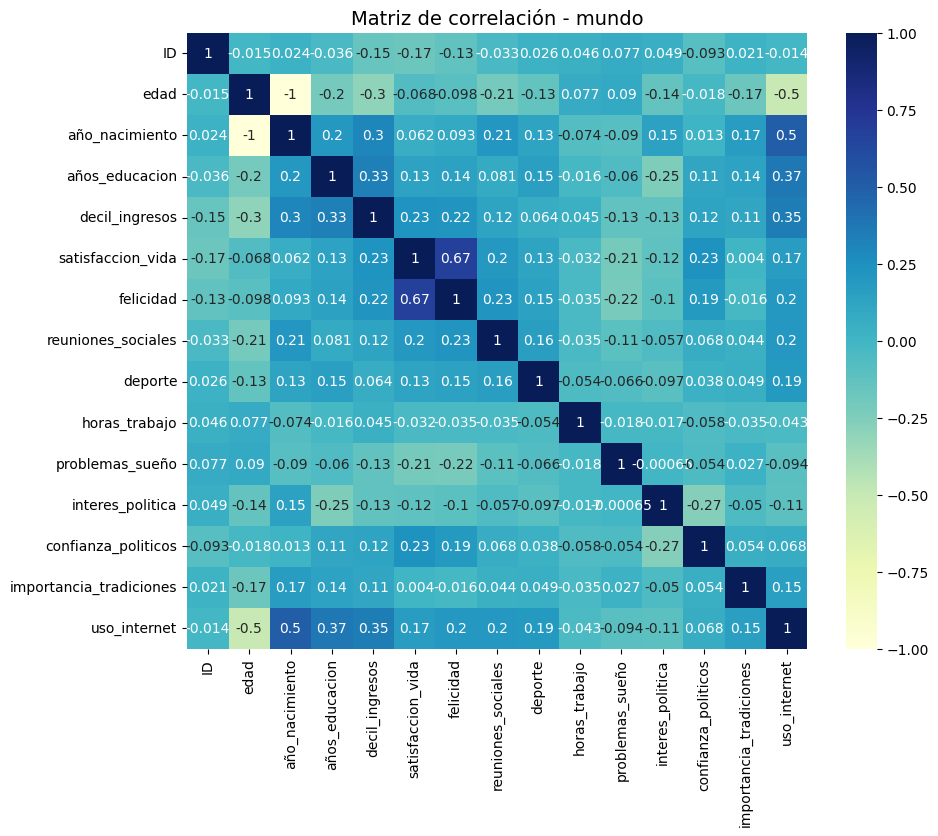

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_world, 
            annot=True, 
            cmap="YlGnBu",
            vmin=-1, vmax=1)
plt.title("Matriz de correlación - mundo", fontsize=14)
plt.show()

El bienestar está fuertemente interrelacionado.
Educación explica ingresos.
Ingresos explican poco la felicidad.
El uso de internet es claramente generacional.
Las variables políticas no parecen muy relacionadas con bienestar.


In [13]:
vars_interes = [
    "felicidad",
    "satisfaccion_vida",
    "decil_ingresos",
    "años_educacion",
    "deporte",
    "interes_politica",
    "horas_trabajo",
    "confianza_politicos",
    "reuniones_sociales"
]

desc_esp = df_esp[vars_interes].mean()
desc_world = df_world[vars_interes].mean()

comparacion_medias = pd.DataFrame({
    "España": desc_esp,
    "Europa": desc_world,
    "Diferencia": desc_esp - desc_world
})

print(comparacion_medias)

                        España     Europa  Diferencia
felicidad             7.850681   7.299031    0.551650
satisfaccion_vida     7.491553   6.982543    0.509011
decil_ingresos        5.394550   5.376879    0.017671
años_educacion       14.428883  13.192094    1.236789
deporte               3.535150   3.209029    0.326120
interes_politica      2.747139   2.649766    0.097373
horas_trabajo        39.949864  38.913047    1.036817
confianza_politicos   2.788011   3.526416   -0.738405
reuniones_sociales    5.256676   4.747766    0.508910


In [14]:
import numpy as np

def cohens_d(x, y):
    nx = len(x)
    ny = len(y)
    pooled_std = np.sqrt(((nx-1)*x.std()**2 + (ny-1)*y.std()**2) / (nx+ny-2))
    return (x.mean() - y.mean()) / pooled_std

for var in vars_interes:
    d = cohens_d(df_esp[var].dropna(), df_world[var].dropna())
    print(var, "Cohen's d:", round(d,3))

felicidad Cohen's d: 0.29
satisfaccion_vida Cohen's d: 0.238
decil_ingresos Cohen's d: 0.007
años_educacion Cohen's d: 0.312
deporte Cohen's d: 0.125
interes_politica Cohen's d: 0.104
horas_trabajo Cohen's d: 0.081
confianza_politicos Cohen's d: -0.305
reuniones_sociales Cohen's d: 0.319


Los efectos más relevantes son:
 Educación (+0.31)
 Reuniones sociales (+0.32)
 Confianza política (-0.30)
 Felicidad (+0.29)
Los demás son pequeños.

España no destaca por ingresos.
Destaca por mayor número de reunionessociales.
Se ve mayor nivel de educación de España.
Presenta mayor bienestar subjetivo.
Y claramente se destaca menor confianza política.
Esto sugiere que el bienestar en España podría estar más vinculado a factores sociales que económicos.

In [15]:
df["grupo"] = df["pais"].apply(lambda x: "España" if x=="ES" else "Resto_mundo")

In [16]:
vars_clave = [
       "felicidad",
    "satisfaccion_vida",
    "decil_ingresos",
    "años_educacion",
    "deporte",
    "interes_politica",
    "horas_trabajo",
    "confianza_politicos",
    "reuniones_sociales"
]

tabla = df.groupby(["generacion","grupo"])[vars_clave].mean().round(2)

print(tabla)

                               felicidad  satisfaccion_vida  decil_ingresos  \
generacion        grupo                                                       
baby boomers      España            7.82               7.54            4.92   
                  Resto_mundo       7.16               6.88            4.55   
gen x             España            7.82               7.46            5.77   
                  Resto_mundo       7.28               6.88            6.02   
gen z             España            7.88               7.58            5.82   
                  Resto_mundo       7.58               7.30            5.84   
millennials       España            8.03               7.46            5.61   
                  Resto_mundo       7.48               7.11            6.13   
silent generation España            7.48               7.32            4.00   
                  Resto_mundo       6.97               6.89            3.55   

                               años_educacion  depo

España es sistemáticamente más feliz.
La diferencia no se explica por ingresos.
España tiene mayor nivel educativo en generaciones activas.
La ventaja española en felicidad es menor en Gen Z.
El patrón generacional (jóvenes más felices) es global.

In [17]:
df.to_csv("../data/datos_paraexcel.csv", index=False)